## Analyse des résultats

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

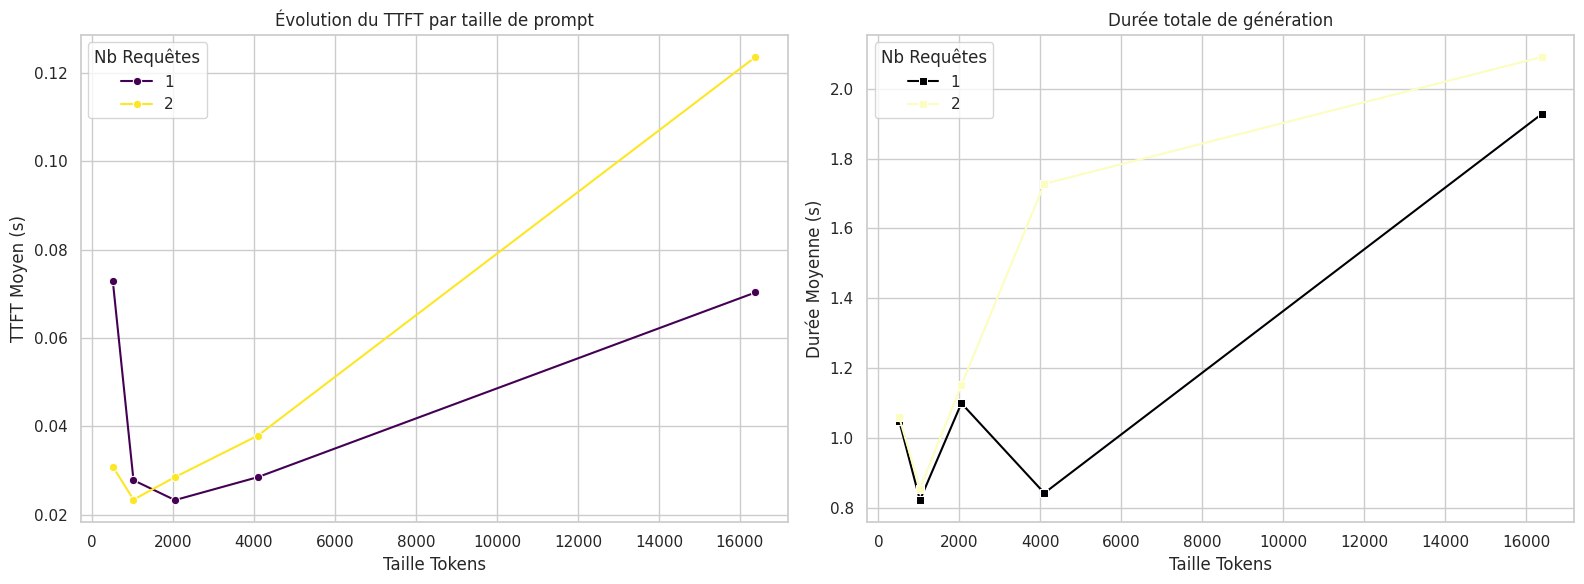

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    with open("resultats_bench.json", "r") as f:
        data = json.load(f)
except FileNotFoundError:
    print("Erreur : Le fichier resultats_bench.json est introuvable.")
    exit()

rows = []
for label, tests in data.items():
    try:
        nb_req = int(label.split()[0])
    except ValueError:
        nb_req = label

    for t in tests:
        rows.append(
            {
                "Nb Requêtes": nb_req,
                "Taille Tokens": t["taille_tokens"],
                "Essai ID": t.get("essai", 0),
                "Durée (s)": t["duree_moyenne"],
                "TTFT (s)": t["ttft_moyen"],
            }
        )

df = pd.DataFrame(rows)

sns.set_theme(style="whitegrid", palette="muted")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Graphique 1 : TTFT avec Écart-Type (Zone d'ombre) ---
# errorbar="sd" trace l'écart-type (Standard Deviation)
sns.lineplot(
    data=df,
    x="Taille Tokens",
    y="TTFT (s)",
    hue="Nb Requêtes",
    marker="o",
    errorbar="sd",
    palette="viridis",
    ax=ax1,
)
ax1.set_title("Réactivité : TTFT Moyen & Écart-Type", fontsize=14, fontweight="bold")
ax1.set_xscale("log", base=2)  # Échelle logarithmique pour les tokens
ax1.set_ylabel("Time To First Token (s)")

# --- Graphique 2 : Durée Totale avec Écart-Type ---
sns.lineplot(
    data=df,
    x="Taille Tokens",
    y="Durée (s)",
    hue="Nb Requêtes",
    marker="s",
    errorbar="sd",
    palette="magma",
    ax=ax2,
)
ax2.set_title("Performance : Durée Totale & Écart-Type", fontsize=14, fontweight="bold")
ax2.set_xscale("log", base=2)
ax2.set_ylabel("Durée totale de génération (s)")


# Optimisation de l'affichage
plt.tight_layout()
plt.suptitle(
    f"Benchmark vLLM (Qwen) - Moyennes sur {df['Essai ID'].max()+1} essais",
    fontsize=16,
    y=1.05,
)

# Sauvegarde du graphique
plt.savefig("analyse_bench_vllm.png", dpi=300, bbox_inches="tight")
plt.show()